# BGL Anomaly Detection: Direct Temporal RAG — Logs-Only KB (E13-E)

**Experiment:** E13-E — Temporal RAG ablation: retrieval from `bgl_logs` collection only.
**Ablation vs:** E08 (Temporal RAG full KB) and E13-A (Vanilla RAG, logs only).
**Strategy:** Same time-decay reranking pipeline as E08 (`0.7 × semantic + 0.3 × exp(−|Δt|/86400)`),
but system-architecture docs (`bgl_architecture`, `bgl_severity`, `bgl_rca`) and role
guides (`role_sre`, `role_devops`) are excluded from retrieval.  Retrieved logs are
still ordered chronologically and presented with time-offset annotations.
**Dataset:** BGL
**Embedding model:** `BAAI/bge-base-en-v1.5`
**Generation model:** `llama-3.1-8b-instant` via Groq API
**Evaluation model:** `qwen/qwen3-32b` via Groq API (LLM-as-judge)
**Vector store:** Qdrant (persistent, shared KB — `bgl_logs` collection only)
**Reference:** E08 (Temporal RAG), E13-A (logs-only ablation baseline)


In [1]:
# =============================================================================
# CELL 1 - PACKAGE INSTALLATION
# =============================================================================
import subprocess
import sys


def install_packages(pkgs):
    for p in pkgs:
        print(f"Installing: {p}")
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", p, "-q"],
            capture_output=True, text=True,
        )
        print("  OK" if r.returncode == 0 else f"  WARN: {r.stderr[:120]}")

install_packages([
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "groq", "tqdm", "sentence-transformers", "qdrant-client",
])
print("\nAll packages ready.")


Installing: pandas
  OK
Installing: numpy
  OK
Installing: scikit-learn
  OK
Installing: matplotlib
  OK
Installing: seaborn
  OK
Installing: groq
  OK
Installing: tqdm
  OK
Installing: sentence-transformers
  OK
Installing: qdrant-client
  OK

All packages ready.


Prompts loaded from : c:\Users\Abhishek Mulay\Desktop\UpgradAIML\Masters\Topics\Revised_Topics\Topic 1\LogSense\Implementation\Experiments\src\Prompts
  Primary Groq keys : 5
  Fallback keys     : 5

Loading BGL structured log ...
  Rows: 2000,  Normal: 1857,  Anomalous: 143

Creating test split ...
  Test Normal    : 200  (93.0%)
  Test Anomalous : 15  (7.0%)
  Test Total     : 215

Connecting to persistent Qdrant KB ...
Collection                Points
----------------------------------
bgl_logs                    3765
bgl_architecture             402
bgl_severity                  80
bgl_rca                       75
hdfs_logs                    300
hdfs_architecture             27
hdfs_severity                 13
hdfs_rca                      15
role_sre                      33
role_devops                   38
  KB client ready

Building temporal timestamp index from BGL dataset ...
  Temporal index: 1373 unique log texts indexed
  Time range: 2005-06-03 23:47  ->  2006-01-03 15:13 U

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10272.19it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Sanity check -- Log hits (5) [Temporal RAG, bgl_logs only]:
  [1] Anomalous combined=0.9351  sem=0.9344  tmp=0.9368  +1.6h  [KERNEL] [FATAL] data TLB error interrupt | Templa
  [2] Anomalous combined=0.9351  sem=0.9344  tmp=0.9368  +1.6h  [KERNEL] [FATAL] data TLB error interrupt | Templa
  [3] Anomalous combined=0.9351  sem=0.9344  tmp=0.9368  +1.6h  [KERNEL] [FATAL] data TLB error interrupt | Templa
  [4] Anomalous combined=0.9351  sem=0.9344  tmp=0.9368  +1.6h  [KERNEL] [FATAL] data TLB error interrupt | Templa
  [5] Anomalous combined=0.9351  sem=0.9344  tmp=0.9368  +1.6h  [KERNEL] [FATAL] data TLB error interrupt | Templa

Running parallel Temporal RAG (logs-only) inference on 215 test samples ...


Temporal RAG (Logs Only) Inference:  31%|███       | 66/215 [01:52<05:38,  2.27s/it]

  [rate-limit] Rotated to fallback key (attempt 1/9)


Temporal RAG (Logs Only) Inference: 100%|██████████| 215/215 [08:43<00:00,  2.44s/it]



  Inference complete. Parse errors: 0 / 215
  Rows with temporal context: 215 / 215 (100.0%)

  EFFICIENCY SUMMARY  [BGL]  Temporal RAG (Logs Only)  (n=215)
  Metric                 Retrieval (ms)   LLM Latency (ms)   Generation (ms)    Total (ms)
----------------------------------------------------------------------------------------
  Mean                           7922.0             2726.4             209.7       10858.0
  Median                         5439.9              910.6              29.2        9501.8
  p95                           21682.2             9717.7             535.3       23504.1
  p99                           25990.0            13731.2            3087.0       27221.6
  Min                             138.7              244.7               5.1         619.0
  Max                           29236.9            14514.8            3588.4       31116.5

  STANDARD METRICS  [BGL]  (Temporal RAG (Logs Only))
  Test set  : 215 (Normal=200, Anomalous=15)
  TP=15  TN=172 

RAG Evaluation: 100%|██████████| 15/15 [14:59<00:00, 59.93s/it]



  RETRIEVAL METRICS  [BGL]  (n=15)
  MRR                   : 1.0000
  Hit Rate @5           : 1.0000
  Context Precision     : 1.0000

  RAGAs METRICS
  Faithfulness          : 0.5667
  Answer Relevance      : 0.8167
  Context Precision     : 1.0000
  Context Recall        : 0.5500

  ADDITIONAL RAG METRICS
  Root Cause Score      : 0.9667
  Evidence Support      : 0.7667
  Severity Agreement    : 1.0000
  Consistency Score     : 0.9763
  Role Appr. (SRE)      : 0.7200
  Role Appr. (DevOps)   : 0.7200
  Completeness Score    : 0.9533


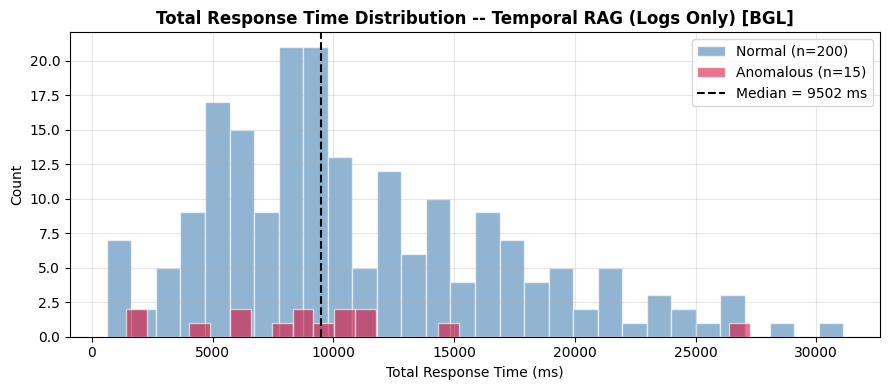

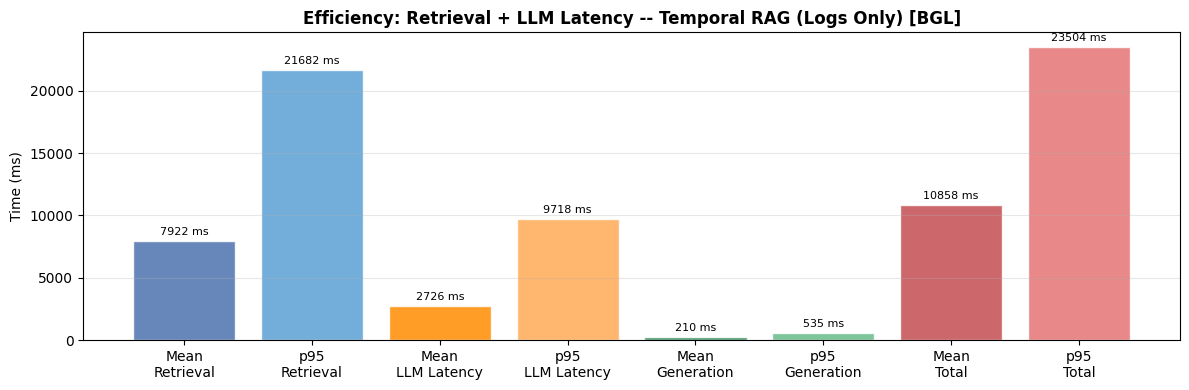

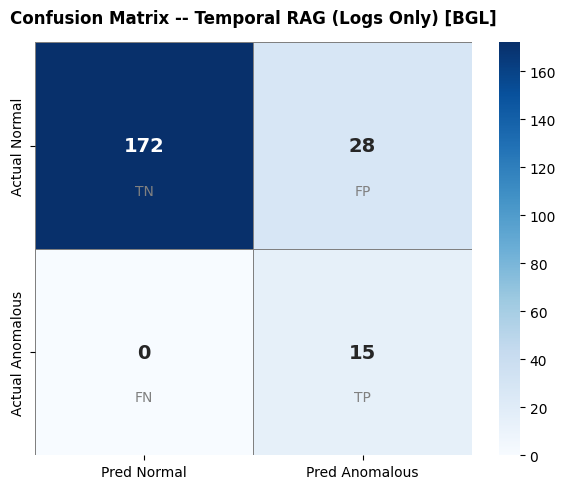

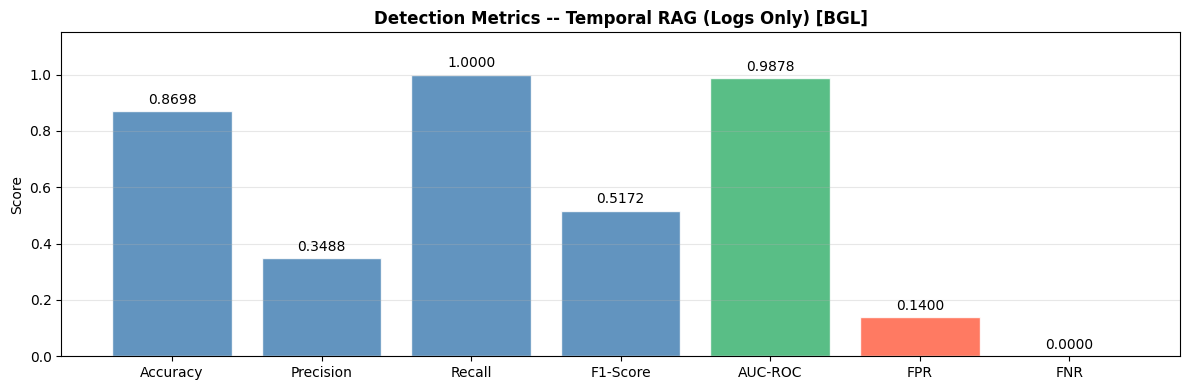

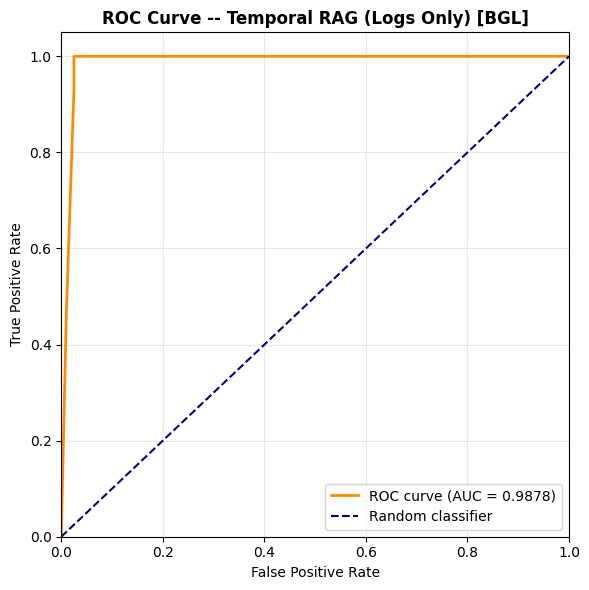

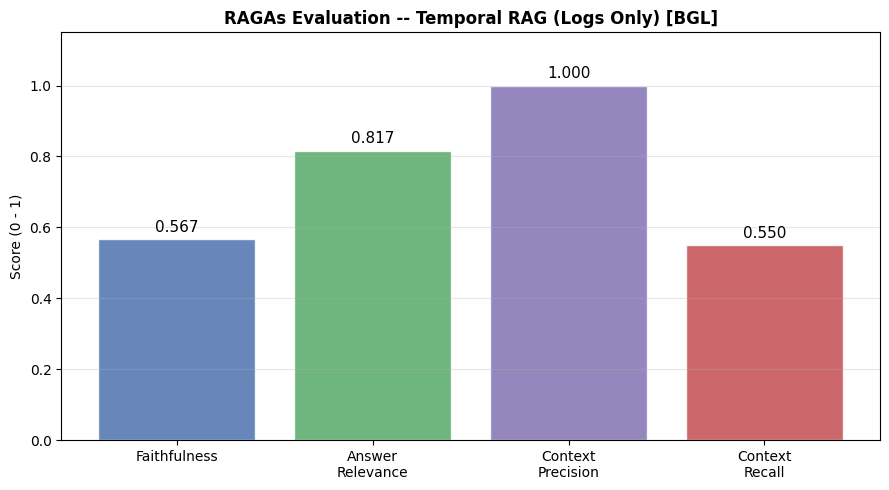

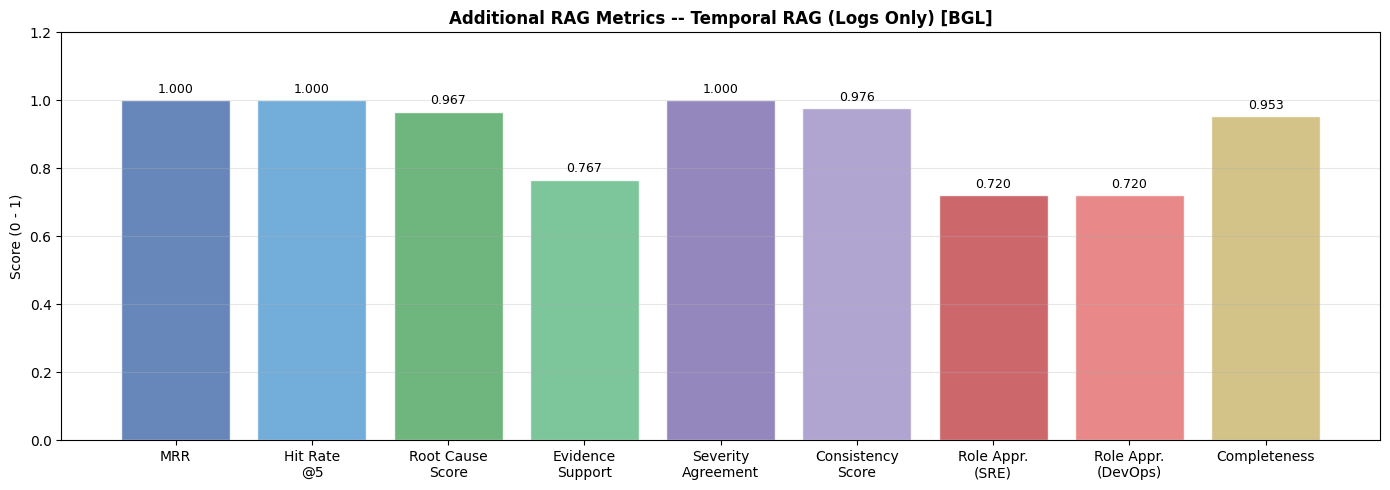

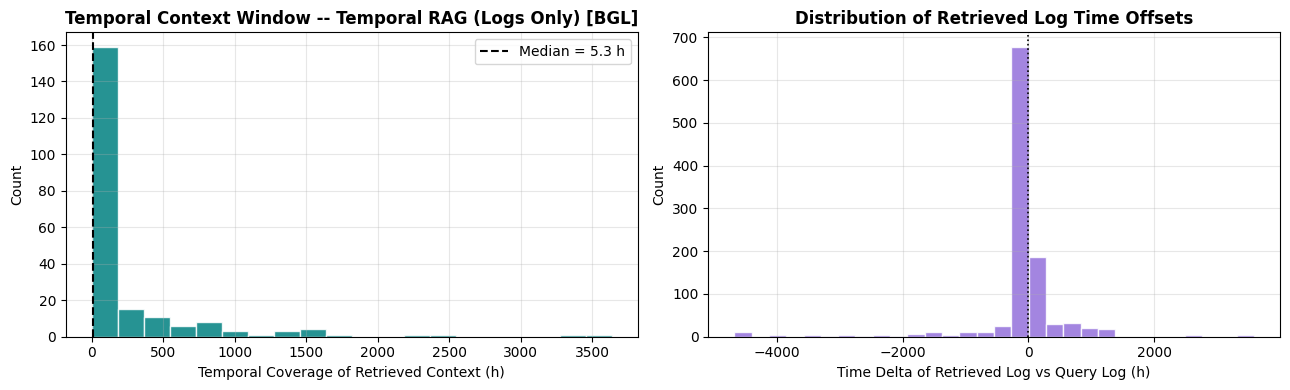


All visualisations complete.


In [2]:
# =============================================================================
# CELL 2 - IMPORTS, CONFIGURATION, DATA LOADING, KB,
#           TEMPORAL INDEX, TEMPORAL RETRIEVAL, INFERENCE, METRICS, VIZ
# =============================================================================
import json
import math
import os
import re
import sys
import time
import warnings
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from groq import Groq
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -- Persistent KB (src/KnowledgeBase/) ---------------------------------------
_KB_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "KnowledgeBase")
)
if _KB_DIR not in sys.path:
    sys.path.insert(0, _KB_DIR)
from kb_utils import KBClient

# -- Shared prompt repository (src/Prompts/) ----------------------------------
_PROMPTS_DIR = os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "Prompts")
)
if _PROMPTS_DIR not in sys.path:
    sys.path.insert(0, _PROMPTS_DIR)

from detection_prompts import (
    BGL_CONFIG,
    build_rag_system_prompt,
    format_retrieved_context,
)
from eval_prompts import (
    JUDGE_SYSTEM_PROMPT,
    build_faithfulness_prompt,
    build_answer_relevance_prompt,
    build_sre_appropriateness_prompt,
    build_devops_appropriateness_prompt,
    build_context_recall_prompt,
    build_root_cause_score_prompt,
    build_evidence_support_prompt,
    build_completeness_prompt_rag,
)
print(f"Prompts loaded from : {_PROMPTS_DIR}")
RAG_SYSTEM_PROMPT = build_rag_system_prompt(BGL_CONFIG)
# =============================================================================
# SECTION 1 - CONFIGURATION
# =============================================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATASET = "BGL"

EMBED_MODEL_NAME = "BAAI/bge-base-en-v1.5"
LLM_MODEL        = "llama-3.1-8b-instant"
EVAL_MODEL       = "qwen/qwen3-32b"

N_FEW_SHOT_NORMAL = 5
N_FEW_SHOT_ANOM   = 5

TEST_NORMAL_CAP  = 200
TEST_ANOMALY_CAP = 15

RETRIEVAL_K        = 5
TEMPORAL_POOL_K    = RETRIEVAL_K * 4
TIME_DECAY_SECONDS = 86_400
TEMPORAL_ALPHA     = 0.7
TEMPORAL_BETA      = 0.3

MAX_RETRIES     = 3
RETRY_DELAY_S   = 5
REQUEST_DELAY_S = 0.5
LLM_MAX_TOKENS  = 900
LLM_TEMPERATURE = 0.0
EVAL_MAX_TOKENS = 1024


def _load_groq_key(n: int) -> Optional[str]:
    p = os.path.abspath(
        os.path.join(
            os.getcwd(), "..", "..", "Keys", f"groq_key_{n}.txt"
        )
    )
    try:
        with open(p) as _f:
            return _f.read().strip()
    except FileNotFoundError:
        return None


_ALL_PRIMARY  = [
    k for k in [_load_groq_key(i) for i in range(1, 6)] if k
]
_ALL_FALLBACK = [
    k for k in [_load_groq_key(i) for i in range(6, 11)] if k
]

if not _ALL_PRIMARY:
    raise FileNotFoundError(
        "No primary Groq keys found. "
        "Expected src/Keys/groq_key_1.txt ... groq_key_5.txt"
    )

GROQ_API_KEY = _ALL_PRIMARY[0]

DATASET_CONFIG = {
    "structured_log_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_structured.csv"
    ),
    "templates_path": (
        "../../../Datasets/BGL/Processed/BGL_2k.log_templates.csv"
    ),
    "label_col":     "Label",
    "normal_value":  "-",
    "event_id_col":  "EventId",
    "component_col": "Component",
    "level_col":     "Level",
    "content_col":   "Content",
    "template_col":  "EventTemplate",
    "timestamp_col": "Timestamp",
}

print(f"  Primary Groq keys : {len(_ALL_PRIMARY)}")
print(f"  Fallback keys     : {len(_ALL_FALLBACK)}")
# =============================================================================
# SECTION 2 - DATA LOADING
# =============================================================================


def build_log_text(row: pd.Series) -> str:
    comp = str(row.get("Component", "")).strip()
    lvl  = str(row.get("Level", "")).strip()
    cont = str(row.get("Content", "")).strip()
    tmpl = str(row.get("EventTemplate", "")).strip()
    return f"[{comp}] [{lvl}] {cont} | Template: {tmpl}"


def load_bgl(config: Dict) -> pd.DataFrame:
    print("\nLoading BGL structured log ...")
    df_logs = pd.read_csv(config["structured_log_path"])
    df_tmpl = pd.read_csv(config["templates_path"])
    df = df_logs.merge(
        df_tmpl, on=config["event_id_col"], how="left",
        suffixes=("", "_tmpl"),
    )
    df["is_normal"]    = df[config["label_col"]] == config["normal_value"]
    df["binary_label"] = (~df["is_normal"]).astype(int)
    df["log_text"]     = df.apply(build_log_text, axis=1)
    df["log_ts"]       = pd.to_numeric(
        df[config["timestamp_col"]], errors="coerce"
    )
    n_norm = int(df["is_normal"].sum())
    n_anom = int((~df["is_normal"]).sum())
    print(f"  Rows: {len(df)},  Normal: {n_norm},  Anomalous: {n_anom}")
    return df


df = load_bgl(DATASET_CONFIG)
# =============================================================================
# SECTION 3 - TEST SPLIT
# =============================================================================


def create_test_split(
    df: pd.DataFrame,
    n_few_shot_normal: int,
    n_few_shot_anom: int,
    test_normal_cap: int,
    test_anomaly_cap: int,
    seed: int = 42,
) -> pd.DataFrame:
    df_n = (
        df[df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    df_a = (
        df[~df["is_normal"]]
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )
    rem_n = df_n.iloc[n_few_shot_normal:].reset_index(drop=True)
    rem_a = df_a.iloc[n_few_shot_anom:].reset_index(drop=True)
    n_t_n = min(test_normal_cap,  len(rem_n))
    n_t_a = min(test_anomaly_cap, len(rem_a))
    if n_t_a < test_anomaly_cap:
        print(
            f"  WARNING: only {n_t_a} anomalies available "
            f"(requested {test_anomaly_cap})."
        )
    return (
        pd.concat(
            [rem_n.iloc[:n_t_n], rem_a.iloc[:n_t_a]],
            ignore_index=True,
        )
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


print("\nCreating test split ...")
test_df = create_test_split(
    df, N_FEW_SHOT_NORMAL, N_FEW_SHOT_ANOM,
    TEST_NORMAL_CAP, TEST_ANOMALY_CAP, RANDOM_SEED,
)
n_tn = int(test_df["is_normal"].sum())
n_ta = int((~test_df["is_normal"]).sum())
print(f"  Test Normal    : {n_tn}  ({n_tn / len(test_df) * 100:.1f}%)")
print(f"  Test Anomalous : {n_ta}  ({n_ta / len(test_df) * 100:.1f}%)")
print(f"  Test Total     : {len(test_df)}")
# =============================================================================
# SECTION 4 - PERSISTENT KNOWLEDGE BASE CLIENT
# =============================================================================
print("\nConnecting to persistent Qdrant KB ...")
kb = KBClient()
kb.collection_stats()
print("  KB client ready")
# =============================================================================
# SECTION 4b - TEMPORAL TIMESTAMP INDEX
#
# A text->timestamp lookup is built from the full BGL CSV.  For each unique
# log_text the median Unix epoch of all matching rows is stored.  This lets
# retrieve() score each KB candidate by temporal proximity to the query log.
#
# Ablation: system/role collections are NOT queried.
# =============================================================================
print("\nBuilding temporal timestamp index from BGL dataset ...")
_df_ts = pd.read_csv(
    DATASET_CONFIG["structured_log_path"],
    usecols=[
        DATASET_CONFIG["event_id_col"],
        DATASET_CONFIG["timestamp_col"],
        DATASET_CONFIG["component_col"],
        DATASET_CONFIG["level_col"],
        DATASET_CONFIG["content_col"],
    ],
)
_df_ts_tmpl = pd.read_csv(DATASET_CONFIG["templates_path"])
_df_ts = _df_ts.merge(
    _df_ts_tmpl, on=DATASET_CONFIG["event_id_col"], how="left",
    suffixes=("", "_tmpl"),
)
_df_ts["log_text"] = _df_ts.apply(build_log_text, axis=1)
_df_ts["ts_num"]   = pd.to_numeric(
    _df_ts[DATASET_CONFIG["timestamp_col"]], errors="coerce"
)
_text_to_ts: Dict[str, float] = (
    _df_ts.groupby("log_text")["ts_num"]
    .median()
    .dropna()
    .astype(float)
    .to_dict()
)
print(f"  Temporal index: {len(_text_to_ts)} unique log texts indexed")

ts_vals = list(_text_to_ts.values())
if ts_vals:
    import datetime
    _ts_min = min(ts_vals)
    _ts_max = max(ts_vals)
    _dt_min = datetime.datetime.utcfromtimestamp(_ts_min).strftime(
        "%Y-%m-%d %H:%M"
    )
    _dt_max = datetime.datetime.utcfromtimestamp(_ts_max).strftime(
        "%Y-%m-%d %H:%M"
    )
    print(f"  Time range: {_dt_min}  ->  {_dt_max} UTC")


def _temporal_score(t_query: float, t_retrieved: float) -> float:
    return math.exp(-abs(t_retrieved - t_query) / TIME_DECAY_SECONDS)


def _format_temporal_context(log_hits: List[Dict]) -> str:
    chron = sorted(
        log_hits, key=lambda h: (h.get("time_delta_h") or 0.0)
    )
    lines = []
    for h in chron:
        td = h.get("time_delta_h")
        if td is not None:
            if td < -0.01:
                t_ctx = f"{abs(td):.1f} h BEFORE query"
            elif td > 0.01:
                t_ctx = f"{td:.1f} h AFTER query"
            else:
                t_ctx = "concurrent with query"
        else:
            t_ctx = "time unknown"
        lines.append(
            f"[Rank {h['rank']} | {h['label']} | "
            f"Score {h['score']:.4f} | {t_ctx}]\n{h['log_text']}"
        )
    return "\n\n".join(lines)
# =============================================================================
# SECTION 5 - TEMPORAL RETRIEVAL (DENSE + TIME-DECAY RERANKING, bgl_logs only)
#
# For each query log:
#   1. Fetch TEMPORAL_POOL_K candidates from Qdrant bgl_logs (dense).
#   2. Look up each candidate's median Unix epoch from _text_to_ts.
#   3. Compute temporal proximity: exp(-|dt| / TIME_DECAY_SECONDS).
#   4. Fuse: combined = TEMPORAL_ALPHA * semantic + TEMPORAL_BETA * temporal.
#   5. Rerank by combined score, return top RETRIEVAL_K.
#   6. Retrieved logs are presented chronologically to the LLM.
#
# Ablation: no system or role collections are queried.
# =============================================================================


def retrieve(
    query_text: str,
    query_ts: Optional[float] = None,
) -> List[Dict]:
    raw_dense = kb.query_bgl_logs(query_text, top_k=TEMPORAL_POOL_K)

    if query_ts is None:
        return [
            {
                "log_text":       h["text"],
                "label":          h.get("label", "Normal"),
                "binary_label":   0 if h.get("label") == "Normal" else 1,
                "score":          round(h["score"], 4),
                "semantic_score": round(h["score"], 4),
                "temporal_score": None,
                "time_delta_h":   None,
                "rank":           i + 1,
            }
            for i, h in enumerate(raw_dense[:RETRIEVAL_K])
        ]

    for h in raw_dense:
        t_h = _text_to_ts.get(h["text"])
        if t_h is not None:
            ts = _temporal_score(query_ts, t_h)
            dh = round((t_h - query_ts) / 3600.0, 2)
        else:
            ts = 0.5
            dh = None
        h["temporal_score"] = ts
        h["time_delta_h"]   = dh
        h["combined_score"] = (
            TEMPORAL_ALPHA * h["score"] + TEMPORAL_BETA * ts
        )

    raw_dense.sort(key=lambda x: x["combined_score"], reverse=True)
    top = raw_dense[:RETRIEVAL_K]

    return [
        {
            "log_text":       h["text"],
            "label":          h.get("label", "Normal"),
            "binary_label":   0 if h.get("label") == "Normal" else 1,
            "score":          round(h["combined_score"], 4),
            "semantic_score": round(h["score"], 4),
            "temporal_score": round(h["temporal_score"], 4),
            "time_delta_h":   h["time_delta_h"],
            "rank":           i + 1,
        }
        for i, h in enumerate(top)
    ]


def _build_user_prompt(log_text: str, log_hits: List[Dict]) -> str:
    temporal_note = (
        "TEMPORAL CONTEXT: Retrieved log examples below are ordered "
        "chronologically relative to the query log's timestamp. "
        "Use time offsets to reason about whether this anomaly is "
        "isolated, recurring, or part of an evolving failure pattern."
        "\n\n"
    )
    log_ctx = (
        temporal_note + _format_temporal_context(log_hits)
        if log_hits else "(none)"
    )
    return (
        f"Log entry to analyze:\n{log_text}\n\n"
        f"Similar log examples from knowledge base:\n{log_ctx}"
    )


_q   = test_df.iloc[0]["log_text"]
_qts = (
    float(test_df.iloc[0]["log_ts"])
    if pd.notna(test_df.iloc[0]["log_ts"]) else None
)
_log_h = retrieve(_q, _qts)
print(f"\nSanity check -- Log hits ({len(_log_h)}) [Temporal RAG, bgl_logs only]:")
for r in _log_h:
    td_str = (
        f"{r['time_delta_h']:+.1f}h"
        if r["time_delta_h"] is not None else "t=?"
    )
    print(
        f"  [{r['rank']}] {r['label']:9s} "
        f"combined={r['score']:.4f}  sem={r['semantic_score']:.4f}"
        f"  tmp={r['temporal_score']}  {td_str}"
        f"  {r['log_text'][:50]}"
    )
# =============================================================================
# SECTION 7 - GROQ CLIENT AND API HELPERS
# =============================================================================
import threading

N_PARALLEL_WORKERS = min(5, len(_ALL_PRIMARY))

_fallback_lock = threading.Lock()
_fallback_pool = list(_ALL_FALLBACK)

_worker_key  = threading.local()
_assign_lock = threading.Lock()
_assign_idx  = [0]


def _init_worker_key() -> None:
    if not hasattr(_worker_key, "current"):
        with _assign_lock:
            idx     = _assign_idx[0] % len(_ALL_PRIMARY)
            stagger = _assign_idx[0]
            _assign_idx[0] += 1
        time.sleep(stagger * 1.0)
        _worker_key.current = _ALL_PRIMARY[idx]


def _rotate_to_fallback() -> bool:
    with _fallback_lock:
        if _fallback_pool:
            _worker_key.current = _fallback_pool.pop(0)
            return True
    return False


def _is_rate_limit(exc: Exception) -> bool:
    s = type(exc).__name__ + " " + str(exc)
    return (
        "ratelimit" in s.lower()
        or "rate_limit" in s.lower()
        or "429" in s
    )


def call_groq(
    system_prompt: str,
    user_message: str,
    model: str,
    max_tokens: int = LLM_MAX_TOKENS,
    temperature: float = LLM_TEMPERATURE,
) -> Tuple[Optional[str], float, float]:
    _init_worker_key()
    budget = MAX_RETRIES + len(_ALL_FALLBACK) + 1
    for attempt in range(budget):
        try:
            client = Groq(api_key=_worker_key.current)
            t0     = time.perf_counter()
            resp   = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens=max_tokens,
                temperature=temperature,
            )
            t1    = time.perf_counter()
            total = (t1 - t0) * 1000.0
            usage = resp.usage
            c_tok = usage.completion_tokens if usage else 1
            p_tok = usage.prompt_tokens if usage else 0
            gen_ms = total * (c_tok / ((p_tok + c_tok) or 1))
            return (
                resp.choices[0].message.content.strip(),
                total - gen_ms,
                gen_ms,
            )
        except Exception as e:
            if _is_rate_limit(e):
                if _rotate_to_fallback():
                    print(
                        f"  [rate-limit] Rotated to fallback key "
                        f"(attempt {attempt + 1}/{budget})",
                        flush=True,
                    )
                    continue
                print(
                    f"  [rate-limit] All keys exhausted -- "
                    f"sleeping 60s (attempt {attempt + 1}/{budget})",
                    flush=True,
                )
                time.sleep(60)
            else:
                time.sleep(RETRY_DELAY_S * min(attempt + 1, 5))
    print(
        f"  [call-groq] All {budget} attempts failed -- returning None",
        flush=True,
    )
    return None, 0.0, 0.0


def _strip_thinking(raw: str) -> str:
    stripped = re.sub(
        "<think>.*?</think>", "", raw, flags=re.DOTALL
    ).strip()
    return stripped if stripped else raw
# =============================================================================
# SECTION 8 - RESPONSE PARSER
# =============================================================================


def _compute_risk(si: Any, et: Any, cp: Any) -> Dict:
    si  = max(1, min(4, int(si)))
    et  = max(1, min(4, int(et)))
    cp  = max(1, min(4, int(cp)))
    tot = round(si * 0.4 + et * 0.3 + cp * 0.2, 3)
    lvl = "High" if tot >= 2.8 else ("Medium" if tot >= 1.8 else "Low")
    return {
        "system_impact": si, "error_type": et, "cascade_potential": cp,
        "total_score": tot, "risk_level": lvl,
    }


def parse_rag_response(raw: Optional[str]) -> Dict:
    default = {
        "label": "Normal", "confidence": 0.5,
        "anomaly_explanation": "",
        "rca_summary": "", "rca_detailed": "",
        "rca_confidence_level": "", "rca_confidence_reasoning": "",
        "rca_causal_chain": [], "rca_supporting_evidence": [],
        "risk_system_impact": 0, "risk_error_type": 0,
        "risk_cascade_potential": 0,
        "risk_total_score": 0.0, "risk_level": "",
        "sre_action": "", "devops_action": "", "parse_error": True,
    }
    if raw is None:
        return default.copy()
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        m = re.search(r"\{.*\}", cleaned, re.DOTALL)
        if m:
            p = json.loads(m.group())
            r = default.copy()
            r["parse_error"] = False
            r["label"]       = str(p.get("label", "Normal"))
            r["confidence"]  = float(
                max(0.0, min(1.0, float(p.get("confidence", 0.5))))
            )
            if r["label"] == "Anomalous":
                r["anomaly_explanation"] = str(
                    p.get("anomaly_explanation", "")
                )
                rca = p.get("rca", {})
                r["rca_summary"]              = str(rca.get("summary", ""))
                r["rca_detailed"]             = str(
                    rca.get("detailed_description", "")
                )
                r["rca_confidence_level"]     = str(
                    rca.get("confidence_level", "")
                )
                r["rca_confidence_reasoning"] = str(
                    rca.get("confidence_reasoning", "")
                )
                r["rca_causal_chain"]         = list(
                    rca.get("causal_chain", [])
                )
                r["rca_supporting_evidence"]  = list(
                    rca.get("supporting_evidence", [])
                )
                rs  = p.get("risk_score", {})
                crs = _compute_risk(
                    rs.get("system_impact", 2),
                    rs.get("error_type", 2),
                    rs.get("cascade_potential", 2),
                )
                r["risk_system_impact"]     = crs["system_impact"]
                r["risk_error_type"]        = crs["error_type"]
                r["risk_cascade_potential"] = crs["cascade_potential"]
                r["risk_total_score"]       = crs["total_score"]
                r["risk_level"]             = crs["risk_level"]
                rem = p.get("remediation", {})
                r["sre_action"]    = str(rem.get("sre_action", ""))
                r["devops_action"] = str(rem.get("devops_action", ""))
            return r
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    return default.copy()
# =============================================================================
# SECTION 9 - TEMPORAL RAG INFERENCE ON TEST SET
# =============================================================================
EXPERIMENT_LABEL = "Temporal RAG (Logs Only)"
PREFIX           = "bgl_temporal_logs_only_rag"

print(
    f"\nRunning parallel Temporal RAG (logs-only) inference on "
    f"{len(test_df)} test samples ..."
)


def _temporal_stats(log_hits: List[Dict]) -> Dict:
    deltas = [
        h["time_delta_h"] for h in log_hits
        if h.get("time_delta_h") is not None
    ]
    n_hits = len(deltas)
    if n_hits == 0:
        return {
            "n_temporal_hits":     0,
            "mean_abs_delta_h":    float("nan"),
            "temporal_coverage_h": float("nan"),
        }
    abs_deltas = [abs(d) for d in deltas]
    return {
        "n_temporal_hits":     n_hits,
        "mean_abs_delta_h":    round(sum(abs_deltas) / n_hits, 2),
        "temporal_coverage_h": round(max(deltas) - min(deltas), 2),
    }


def _run_rag_inference(row_dict: dict) -> dict:
    query_ts = (
        float(row_dict["log_ts"])
        if row_dict.get("log_ts") is not None
        and not (
            isinstance(row_dict["log_ts"], float)
            and math.isnan(row_dict["log_ts"])
        )
        else None
    )
    t_ret0      = time.perf_counter()
    log_hits    = retrieve(row_dict["log_text"], query_ts)
    ret_ms      = (time.perf_counter() - t_ret0) * 1000.0
    user_prompt = _build_user_prompt(row_dict["log_text"], log_hits)
    raw, l_ms, g_ms = call_groq(RAG_SYSTEM_PROMPT, user_prompt, LLM_MODEL)
    parsed                        = parse_rag_response(raw)
    parsed["true_label"]          = int(row_dict["binary_label"])
    parsed["log_text"]            = row_dict["log_text"]
    parsed["raw_response"]        = raw
    parsed["retrieved_docs"]      = log_hits
    parsed["knowledge_docs"]      = []         # no supplementary knowledge retrieved
    parsed["retrieval_ms"]        = ret_ms
    parsed["latency_ms"]          = l_ms
    parsed["generation_ms"]       = g_ms
    ts_stats                      = _temporal_stats(log_hits)
    parsed["n_temporal_hits"]     = ts_stats["n_temporal_hits"]
    parsed["mean_abs_delta_h"]    = ts_stats["mean_abs_delta_h"]
    parsed["temporal_coverage_h"] = ts_stats["temporal_coverage_h"]
    return parsed


rows    = test_df.to_dict("records")
results: List[Dict] = [None] * len(rows)

with ThreadPoolExecutor(max_workers=N_PARALLEL_WORKERS) as executor:
    future_to_idx = {
        executor.submit(_run_rag_inference, row): idx
        for idx, row in enumerate(rows)
    }
    for future in tqdm(
        as_completed(future_to_idx),
        total=len(rows),
        desc="Temporal RAG (Logs Only) Inference",
    ):
        idx = future_to_idx[future]
        try:
            results[idx] = future.result()
        except Exception as exc:
            print(f"  Worker error on row {idx}: {exc}")
            results[idx] = {
                "true_label": int(rows[idx]["binary_label"]),
                "log_text": rows[idx]["log_text"],
                "label": "Normal", "confidence": 0.5,
                "parse_error": True, "raw_response": None,
                "retrieved_docs": [], "knowledge_docs": [],
                "retrieval_ms": 0.0, "latency_ms": 0.0,
                "generation_ms": 0.0,
                "n_temporal_hits": 0,
                "mean_abs_delta_h": float("nan"),
                "temporal_coverage_h": float("nan"),
            }

results_df = pd.DataFrame(results)
results_df["pred_label"] = results_df["label"].apply(
    lambda x: 1 if str(x).strip().lower() == "anomalous" else 0
)
print(
    f"\n  Inference complete. "
    f"Parse errors: {int(results_df['parse_error'].sum())} "
    f"/ {len(results_df)}"
)
_n_ts = int((results_df["n_temporal_hits"] > 0).sum())
print(
    f"  Rows with temporal context: {_n_ts} / {len(results_df)} "
    f"({_n_ts / len(results_df) * 100:.1f}%)"
)
# =============================================================================
# SECTION 10 - EFFICIENCY SUMMARY
# =============================================================================
ret_arr = results_df["retrieval_ms"].values
lat_arr = results_df["latency_ms"].values
gen_arr = results_df["generation_ms"].values
tot_arr = ret_arr + lat_arr + gen_arr

print("\n" + "=" * 82)
print(
    f"  EFFICIENCY SUMMARY  [{DATASET}]  {EXPERIMENT_LABEL}"
    f"  (n={len(results_df)})"
)
print("=" * 82)
print(
    f"  {'Metric':<20}  {'Retrieval (ms)':>15}  {'LLM Latency (ms)':>17}  "
    f"{'Generation (ms)':>16}  {'Total (ms)':>12}"
)
print("-" * 88)


def _pct95(x):
    return np.percentile(x, 95)


def _pct99(x):
    return np.percentile(x, 99)


_stat_fns = {
    "Mean":   np.mean,
    "Median": np.median,
    "p95":    _pct95,
    "p99":    _pct99,
    "Min":    np.min,
    "Max":    np.max,
}
for lbl, fn in _stat_fns.items():
    print(
        f"  {lbl:<20}  {fn(ret_arr):>15.1f}  "
        f"{fn(lat_arr):>17.1f}  "
        f"{fn(gen_arr):>16.1f}  {fn(tot_arr):>12.1f}"
    )
print("=" * 82)

latency_summary = {
    "mean_retrieval_ms":  float(ret_arr.mean()),
    "p95_retrieval_ms":   float(np.percentile(ret_arr, 95)),
    "mean_latency_ms":    float(lat_arr.mean()),
    "p95_latency_ms":     float(np.percentile(lat_arr, 95)),
    "mean_generation_ms": float(gen_arr.mean()),
    "p95_generation_ms":  float(np.percentile(gen_arr, 95)),
    "mean_total_ms":      float(tot_arr.mean()),
    "p95_total_ms":       float(np.percentile(tot_arr, 95)),
}
# =============================================================================
# SECTION 11 - STANDARD ANOMALY DETECTION METRICS
# =============================================================================
y_true   = results_df["true_label"].tolist()
y_pred   = results_df["pred_label"].tolist()
y_scores = [
    c if lbl == "Anomalous" else 1.0 - c
    for c, lbl in zip(results_df["confidence"], results_df["label"])
]

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
try:
    auc = roc_auc_score(y_true, y_scores)
except ValueError:
    auc = float("nan")
fpr_curve, tpr_curve, _ = roc_curve(y_true, y_scores)

n_pos, n_neg = y_true.count(1), y_true.count(0)
print("\n" + "=" * 64)
print(f"  STANDARD METRICS  [{DATASET}]  ({EXPERIMENT_LABEL})")
print("=" * 64)
print(f"  Test set  : {len(y_true)} (Normal={n_neg}, Anomalous={n_pos})")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print("-" * 64)
print(f"  Accuracy   : {acc:.4f}  ({acc * 100:.2f}%)")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  FPR        : {fpr_val:.4f}")
print(f"  FNR        : {fnr_val:.4f}")
print(f"  AUC-ROC    : {auc:.4f}")
print("=" * 64)

std_metrics = dict(
    accuracy=acc, precision=prec, recall=rec, f1=f1,
    tp=int(tp), tn=int(tn), fp=int(fp), fn=int(fn), cm=cm,
    fpr=fpr_val, fnr=fnr_val, auc_roc=auc,
    fpr_curve=fpr_curve, tpr_curve=tpr_curve,
)
# =============================================================================
# SECTION 12 - RAG EVALUATION METRICS
# =============================================================================


def score_with_judge(prompt: str) -> Tuple[float, str]:
    raw, _, _ = call_groq(
        JUDGE_SYSTEM_PROMPT, prompt, EVAL_MODEL,
        max_tokens=EVAL_MAX_TOKENS, temperature=0.0,
    )
    if raw is None:
        return 0.0, "API error"
    content = _strip_thinking(raw)
    try:
        c = re.sub(r"```(?:json)?\s*", "", content).strip().rstrip("`")
        m = re.search(r"\{.*\}", c, re.DOTALL)
        if m:
            p = json.loads(m.group())
            return (
                max(0.0, min(1.0, float(p.get("score", 0.0)))),
                str(p.get("reason", "")),
            )
    except (json.JSONDecodeError, ValueError, TypeError):
        pass
    nums = re.findall(r"\b0\.\d+\b|\b1\.0\b|\b[01]\b", content)
    if nums:
        return max(0.0, min(1.0, float(nums[0]))), content[:80]
    return 0.0, "Parse error"


def _mrr(retrieved: List[Dict], true_label: int) -> float:
    for d in retrieved:
        if d["binary_label"] == true_label:
            return 1.0 / d["rank"]
    return 0.0


def _hit_at_k(retrieved: List[Dict], true_label: int) -> float:
    return (
        1.0 if any(
            d["binary_label"] == true_label for d in retrieved
        ) else 0.0
    )


def _context_precision(retrieved: List[Dict], true_label: int) -> float:
    if not retrieved:
        return 0.0
    return sum(
        1 for d in retrieved if d["binary_label"] == true_label
    ) / len(retrieved)


def _expected_severity(log_text: str) -> str:
    if "[FATAL]" in log_text:
        return "High"
    if "[ERROR]" in log_text:
        return "Medium"
    return "Low"


def _consistency_score(anom_df: pd.DataFrame) -> float:
    if len(anom_df) < 2:
        return 1.0
    tmp = anom_df.copy()
    tmp["tmpl"] = tmp["log_text"].str.extract("Template:\\s*(.+)$")
    stds = (
        tmp.groupby("tmpl")["risk_total_score"].std(ddof=0).fillna(0.0)
    )
    return float((1.0 - (stds / 1.35).clip(0.0, 1.0)).mean())


eval_df = results_df[
    results_df["true_label"] == 1
].reset_index(drop=True)
print(
    f"\nLLM-as-judge on {len(eval_df)} true anomalies "
    f"(judge: {EVAL_MODEL}) ...\n"
)

retrieval_rows, ragas_rows, extra_rows = [], [], []

for _, row in tqdm(
    eval_df.iterrows(), total=len(eval_df), desc="RAG Evaluation"
):
    retrieved = (
        row["retrieved_docs"]
        if isinstance(row["retrieved_docs"], list) else []
    )
    true_lbl  = int(row["true_label"])
    log_text  = row["log_text"]
    anon_expl = str(row.get("anomaly_explanation", ""))
    rca_sum   = str(row.get("rca_summary", ""))
    rca_det   = str(row.get("rca_detailed", ""))
    rca_cl    = str(row.get("rca_confidence_level", ""))
    rca_cr    = str(row.get("rca_confidence_reasoning", ""))
    causal_ch = row.get("rca_causal_chain", [])
    supp_ev   = row.get("rca_supporting_evidence", [])
    risk_tot  = float(row.get("risk_total_score", 0.0))
    risk_lvl  = str(row.get("risk_level", ""))
    sre_act   = str(row.get("sre_action", ""))
    dev_act   = str(row.get("devops_action", ""))

    ctx_text = (
        "Similar logs (temporal, bgl_logs only):\n"
        + (
            _format_temporal_context(retrieved)
            if retrieved else "(none)"
        )
    )

    cp_s = _context_precision(retrieved, true_lbl)
    retrieval_rows.append({
        "mrr":               _mrr(retrieved, true_lbl),
        "hit_at_k":          _hit_at_k(retrieved, true_lbl),
        "context_precision": cp_s,
    })
    time.sleep(REQUEST_DELAY_S)

    faith_s, _ = score_with_judge(
        build_faithfulness_prompt(log_text, rca_sum, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    relev_s, _ = score_with_judge(
        build_answer_relevance_prompt(log_text, anon_expl, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ctx_rec_s, _ = score_with_judge(
        build_context_recall_prompt(log_text, ctx_text, rca_sum)
    )
    time.sleep(REQUEST_DELAY_S)
    ragas_rows.append({
        "faithfulness":      faith_s,
        "answer_relevance":  relev_s,
        "context_precision": cp_s,
        "context_recall":    ctx_rec_s,
    })

    rcs_s,  _ = score_with_judge(
        build_root_cause_score_prompt(
            log_text, rca_sum, rca_det, causal_ch
        )
    )
    time.sleep(REQUEST_DELAY_S)
    evid_s, _ = score_with_judge(
        build_evidence_support_prompt(log_text, supp_ev)
    )
    time.sleep(REQUEST_DELAY_S)
    sre_s,  _ = score_with_judge(
        build_sre_appropriateness_prompt(sre_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    dev_s,  _ = score_with_judge(
        build_devops_appropriateness_prompt(dev_act, log_text)
    )
    time.sleep(REQUEST_DELAY_S)
    comp_s, _ = score_with_judge(
        build_completeness_prompt_rag(
            anon_expl, rca_sum, rca_det, rca_cl, rca_cr,
            causal_ch, supp_ev, risk_tot, sre_act, dev_act,
        )
    )
    time.sleep(REQUEST_DELAY_S)
    extra_rows.append({
        "root_cause_score":            rcs_s,
        "evidence_support_score":      evid_s,
        "severity_agreement":          (
            1.0 if risk_lvl == _expected_severity(log_text) else 0.0
        ),
        "consistency_score":           0.0,
        "role_appropriateness_sre":    sre_s,
        "role_appropriateness_devops": dev_s,
        "completeness_score":          comp_s,
    })

cons_score = _consistency_score(eval_df)
for e in extra_rows:
    e["consistency_score"] = cons_score

ret_df   = pd.DataFrame(retrieval_rows)
ragas_df = pd.DataFrame(ragas_rows)
extra_df = pd.DataFrame(extra_rows)
mr_ret   = ret_df.mean()
mr_rag   = ragas_df.mean()
mr_ext   = extra_df.mean()

print("\n" + "=" * 64)
print(f"  RETRIEVAL METRICS  [{DATASET}]  (n={len(eval_df)})")
print("=" * 64)
print(f"  MRR                   : {mr_ret['mrr']:.4f}")
print(f"  Hit Rate @{RETRIEVAL_K}           : {mr_ret['hit_at_k']:.4f}")
print(f"  Context Precision     : {mr_ret['context_precision']:.4f}")
print("\n  RAGAs METRICS")
print("=" * 64)
print(f"  Faithfulness          : {mr_rag['faithfulness']:.4f}")
print(f"  Answer Relevance      : {mr_rag['answer_relevance']:.4f}")
print(f"  Context Precision     : {mr_rag['context_precision']:.4f}")
print(f"  Context Recall        : {mr_rag['context_recall']:.4f}")
print("\n  ADDITIONAL RAG METRICS")
print("=" * 64)
print(f"  Root Cause Score      : {mr_ext['root_cause_score']:.4f}")
print(f"  Evidence Support      : {mr_ext['evidence_support_score']:.4f}")
print(f"  Severity Agreement    : {mr_ext['severity_agreement']:.4f}")
print(f"  Consistency Score     : {mr_ext['consistency_score']:.4f}")
print(
    f"  Role Appr. (SRE)      : "
    f"{mr_ext['role_appropriateness_sre']:.4f}"
)
print(
    f"  Role Appr. (DevOps)   : "
    f"{mr_ext['role_appropriateness_devops']:.4f}"
)
print(f"  Completeness Score    : {mr_ext['completeness_score']:.4f}")
print("=" * 64)

all_metrics = {**std_metrics, **latency_summary}
all_metrics["mrr"]      = float(mr_ret["mrr"])
all_metrics["hit_at_k"] = float(mr_ret["hit_at_k"])
for k, v in {**mr_rag, **mr_ext}.items():
    all_metrics[k] = float(v)
# =============================================================================
# SECTION 13 - VISUALISATIONS
# =============================================================================
y_arr = np.array(y_true)

# 13a -- Response time distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    tot_arr[y_arr == 0], bins=30, alpha=0.6, color="steelblue",
    label=f"Normal (n={(y_arr == 0).sum()})", edgecolor="white",
)
ax.hist(
    tot_arr[y_arr == 1], bins=30, alpha=0.6, color="crimson",
    label=f"Anomalous (n={(y_arr == 1).sum()})", edgecolor="white",
)
ax.axvline(
    float(np.median(tot_arr)), color="black", linestyle="--", lw=1.5,
    label=f"Median = {np.median(tot_arr):.0f} ms",
)
ax.set_xlabel("Total Response Time (ms)")
ax.set_ylabel("Count")
ax.set_title(
    f"Total Response Time Distribution -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_response_time_dist.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13b -- Latency breakdown bar chart
lat_data = {
    "Mean\nRetrieval":   latency_summary["mean_retrieval_ms"],
    "p95\nRetrieval":    latency_summary["p95_retrieval_ms"],
    "Mean\nLLM Latency": latency_summary["mean_latency_ms"],
    "p95\nLLM Latency":  latency_summary["p95_latency_ms"],
    "Mean\nGeneration":  latency_summary["mean_generation_ms"],
    "p95\nGeneration":   latency_summary["p95_generation_ms"],
    "Mean\nTotal":       latency_summary["mean_total_ms"],
    "p95\nTotal":        latency_summary["p95_total_ms"],
}
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    list(lat_data.keys()), list(lat_data.values()),
    color=[
        "#4C72B0", "#5a9fd4", "darkorange", "#ffaa55",
        "seagreen", "#66bb8a", "#C44E52", "#e57373",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.0f ms", padding=3, fontsize=8)
ax.set_ylabel("Time (ms)")
ax.set_title(
    f"Efficiency: Retrieval + LLM Latency -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_latency_breakdown.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13c -- Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Normal", "Pred Anomalous"],
    yticklabels=["Actual Normal", "Actual Anomalous"],
    linewidths=0.5, linecolor="gray",
    annot_kws={"size": 14, "weight": "bold"}, ax=ax,
)
for (r, c), lbl in {
    (0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"
}.items():
    ax.text(
        c + 0.5, r + 0.72, lbl,
        ha="center", va="center", fontsize=10, color="grey",
    )
ax.set_title(
    f"Confusion Matrix -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold", pad=14,
)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_confusion_matrix.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13d -- Standard detection metrics
det_names  = [
    "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "FPR", "FNR"
]
det_values = [acc, prec, rec, f1, auc, fpr_val, fnr_val]
det_colours = ["steelblue"] * 4 + ["mediumseagreen"] + ["tomato"] * 2
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    det_names, det_values,
    color=det_colours, edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title(
    f"Detection Metrics -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_detection_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13e -- ROC curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(
    fpr_curve, tpr_curve, color="darkorange", lw=2,
    label=f"ROC curve (AUC = {auc:.4f})",
)
ax.plot(
    [0, 1], [0, 1], color="navy", lw=1.5, linestyle="--",
    label="Random classifier",
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(
    f"ROC Curve -- {EXPERIMENT_LABEL} [{DATASET}]", fontweight="bold"
)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PREFIX}_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# 13f -- RAGAs metrics
ragas_names  = [
    "Faithfulness", "Answer\nRelevance",
    "Context\nPrecision", "Context\nRecall",
]
ragas_values = [
    float(mr_rag[k]) for k in [
        "faithfulness", "answer_relevance",
        "context_precision", "context_recall",
    ]
]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    ragas_names, ragas_values,
    color=["#4C72B0", "#55A868", "#8172B2", "#C44E52"],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"RAGAs Evaluation -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_ragas_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13g -- Additional RAG metrics
extra_names  = [
    "MRR", f"Hit Rate\n@{RETRIEVAL_K}", "Root Cause\nScore",
    "Evidence\nSupport", "Severity\nAgreement", "Consistency\nScore",
    "Role Appr.\n(SRE)", "Role Appr.\n(DevOps)", "Completeness",
]
extra_values = [
    float(mr_ret["mrr"]), float(mr_ret["hit_at_k"]),
    float(mr_ext["root_cause_score"]),
    float(mr_ext["evidence_support_score"]),
    float(mr_ext["severity_agreement"]),
    float(mr_ext["consistency_score"]),
    float(mr_ext["role_appropriateness_sre"]),
    float(mr_ext["role_appropriateness_devops"]),
    float(mr_ext["completeness_score"]),
]
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    extra_names, extra_values,
    color=[
        "#4C72B0", "#5a9fd4", "#55A868", "#66bb8a",
        "#8172B2", "#a395c9", "#C44E52", "#e57373", "#CCB974",
    ],
    edgecolor="white", alpha=0.85,
)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Score (0 - 1)")
ax.set_title(
    f"Additional RAG Metrics -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    f"{PREFIX}_additional_rag_metrics.png", dpi=150, bbox_inches="tight"
)
plt.show()

# 13h -- Temporal coverage distribution
_cov = results_df["temporal_coverage_h"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(_cov, bins=20, color="teal", edgecolor="white", alpha=0.85)
ax.axvline(
    float(_cov.median()), color="black", linestyle="--", lw=1.5,
    label=f"Median = {_cov.median():.1f} h",
)
ax.set_xlabel("Temporal Coverage of Retrieved Context (h)")
ax.set_ylabel("Count")
ax.set_title(
    f"Temporal Context Window -- {EXPERIMENT_LABEL} [{DATASET}]",
    fontweight="bold",
)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
_all_deltas = [
    h["time_delta_h"]
    for docs in results_df["retrieved_docs"]
    if isinstance(docs, list)
    for h in docs
    if h.get("time_delta_h") is not None
]
if _all_deltas:
    ax.hist(
        _all_deltas, bins=30, color="mediumpurple",
        edgecolor="white", alpha=0.85,
    )
    ax.axvline(0, color="black", lw=1.2, linestyle=":")
    ax.set_xlabel("Time Delta of Retrieved Log vs Query Log (h)")
    ax.set_ylabel("Count")
    ax.set_title(
        "Distribution of Retrieved Log Time Offsets",
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)
else:
    ax.text(
        0.5, 0.5, "No temporal data available",
        ha="center", va="center", transform=ax.transAxes,
    )

plt.tight_layout()
plt.savefig(
    f"{PREFIX}_temporal_coverage.png", dpi=150, bbox_inches="tight"
)
plt.show()

print("\nAll visualisations complete.")


In [ ]:
# =============================================================================
# CELL 3 - ANOMALY OUTPUT INSPECTION
# Prints all generated fields for true anomalies.
# =============================================================================
anom_df = results_df[results_df["true_label"] == 1].reset_index(drop=True)
print(f"True anomalies in results: {len(anom_df)}\n")
print("=" * 90)
for _, row in anom_df.iterrows():
    print(f"LOG   : {row['log_text']}")
    print(f"PRED  : {row['label']}  (conf={row['confidence']:.2f})")
    print(f"EXPL  : {row.get('anomaly_explanation','')[:120]}")
    print(f"RCA   : {row.get('rca_summary','')[:120]}")
    print(
        f"RISK  : {row.get('risk_level','')}  "
        f"(score={row.get('risk_total_score',0):.2f})"
    )
    print(f"SRE   : {row.get('sre_action','')[:100]}")
    print(f"DEVOPS: {row.get('devops_action','')[:100]}")
    cov   = row.get('temporal_coverage_h', float('nan'))
    nhits = row.get('n_temporal_hits', 0)
    print(
        f"TEMPO : coverage={cov:.1f}h  "
        f"temporal_hits={nhits}"
    )
    print("=" * 90)
